In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

Get data

In [3]:
mnist_bldr = tfds.builder('mnist')
mnist_bldr.download_and_prepare() 
datasets = mnist_bldr.as_dataset(shuffle_files=False) 
mnist_train_orig = datasets['train'] 
mnist_test_orig = datasets['test']

BUFFER_SIZE = 10000 
BATCH_SIZE = 64 
NUM_EPOCHS = 10 

mnist_train = mnist_train_orig.map( lambda item: (tf.cast(item['image'], tf.float32)/255.0, tf.cast(item['label'], tf.int32)))
mnist_test =   mnist_test_orig.map( lambda item: (tf.cast(item['image'], tf.float32)/255.0, tf.cast(item['label'], tf.int32)))

tf.random.set_seed(1)
mnist_train = mnist_train.shuffle(buffer_size=BUFFER_SIZE, reshuffle_each_iteration=False)
mnist_valid = mnist_train.take(10000).batch(BATCH_SIZE)
mnist_train = mnist_train.skip(10000).batch(BATCH_SIZE)


Create CNN+BiLSTM+CTC model

In [4]:
# Input shape: (batch_size, height, width, channels)
input_shape = (28, 28, 1)
inputs = tf.keras.Input(shape=input_shape)

# CNN feature extractor
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (14, 14, 32)
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (7, 7, 64)

# Reshape CNN output to (sequence_length, feature_dim)
features = layers.Reshape((7, 7*64))(x)        # (batch, 7 steps, 448 features)

# BiLSTM layer
lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(features)

# Add one extra class for "CTC blank"
num_classes = 11
outputs = layers.Dense(num_classes, activation="softmax")(lstm_out)

# Define the model
model = models.Model(inputs, outputs)
model.summary()

# CTC loss function
def ctc_loss(y_true, y_pred):
    batch_size = tf.shape(y_pred)[0]
    input_length = tf.fill([batch_size, 1], tf.shape(y_pred)[1])  # all 7
    # Reshape and pad y_true to match expected shape for CTC
    y_true = tf.reshape(y_true, [-1, 1])  # Reshape to have a sequence length of 1
    padding = tf.constant([[0, 0], [0, 6]]) # Pad to sequence length 7
    y_true = tf.pad(y_true, padding, "CONSTANT", constant_values=-1)

    label_length = tf.math.count_nonzero(tf.not_equal(y_true, -1), axis=-1, keepdims=True)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)


# Compile with CTC loss
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=ctc_loss)
history = model.fit(mnist_train, epochs=NUM_EPOCHS, validation_data=mnist_valid, shuffle=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 448)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 7, 256)         │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7, 11)          │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 612,491 (2.34 MB)

 Trainable params: 612,491 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


2025-09-17 20:18:53.018170: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - loss: 0.7809 - val_loss: 0.1083
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - loss: 0.0771 - val_loss: 0.0595
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 0.0460 - val_loss: 0.0503
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 0.0300 - val_loss: 0.0401
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 963s 1s/step - loss: 0.0223 - val_loss: 0.0354
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2962s 4s/step - loss: 0.0168 - val_loss: 0.0393
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - loss: 0.0158 - val_loss: 0.0432
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 0.0100 - val_loss: 0.0384
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 0.0101 - val_loss: 0.0343
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - loss: 0.0092 - val_loss: 0.0408


Get sample set

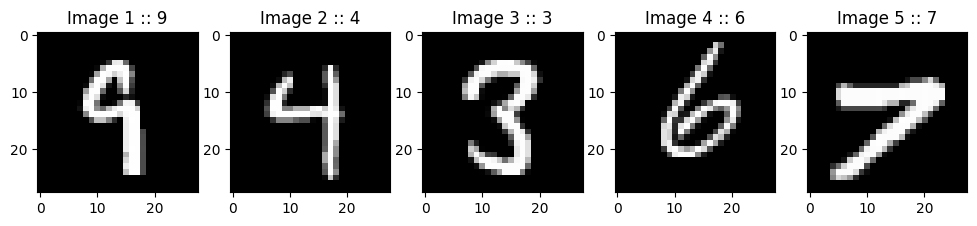

In [11]:
# Get a batch from mnist_train and select two images
batch = next(iter(mnist_train))
random_id = np.random.choice(batch[0].shape[0], 5, replace=False)
dummy_images = tf.gather(batch[0], random_id).numpy()
true_labels = tf.gather(batch[1], random_id).numpy()

fig, axes = plt.subplots(1, dummy_images.shape[0], figsize=(12, 4))
for i in range(dummy_images.shape[0]):
    # Show the mean across channels for visualization
    axes[i].imshow(np.mean(dummy_images[i], axis=-1), cmap='gray')
    axes[i].set_title(f"Image {i+1} :: {true_labels[i]}")

Show CNN output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
CNN features shape: (5, 7, 448)


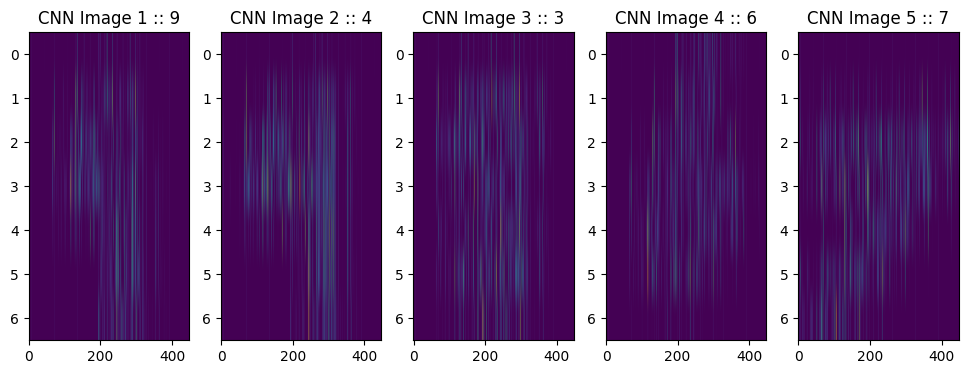

In [12]:

# Get CNN features for dummy_images
cnn_model = models.Model(inputs, features)
# cnn_model = models.Model(inputs, x)
cnn_features = cnn_model.predict(dummy_images)

print("CNN features shape:", cnn_features.shape)
fig, axes = plt.subplots(1, cnn_features.shape[0], figsize=(12, 4))
for i in range(cnn_features.shape[0]):
    # Show the mean across channels for visualization
    # axes[i].imshow(np.mean(cnn_features[i], axis=-1), cmap='viridis')
    axes[i].imshow(cnn_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"CNN Image {i+1} :: {true_labels[i]}")



Show BiLSTM output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
BiLSTM features shape: (5, 7, 256)


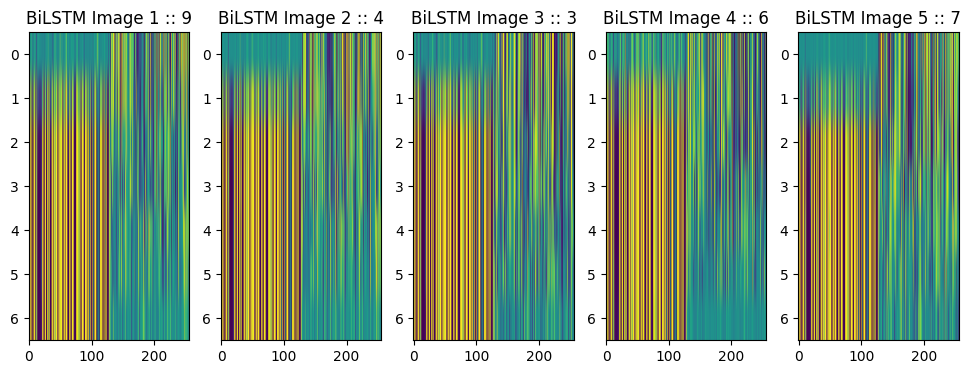

In [13]:
biLSTM = models.Model(inputs, lstm_out)
biLSTM_features = biLSTM.predict(dummy_images)

print("BiLSTM features shape:", biLSTM_features.shape)
fig, axes = plt.subplots(1, biLSTM_features.shape[0], figsize=(12, 4))
for i in range(biLSTM_features.shape[0]):
    # Show the BiLSTM output as a heatmap: shape (7, 11)
    axes[i].imshow(biLSTM_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"BiLSTM Image {i+1} :: {true_labels[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Full output shape: (5, 7, 11)


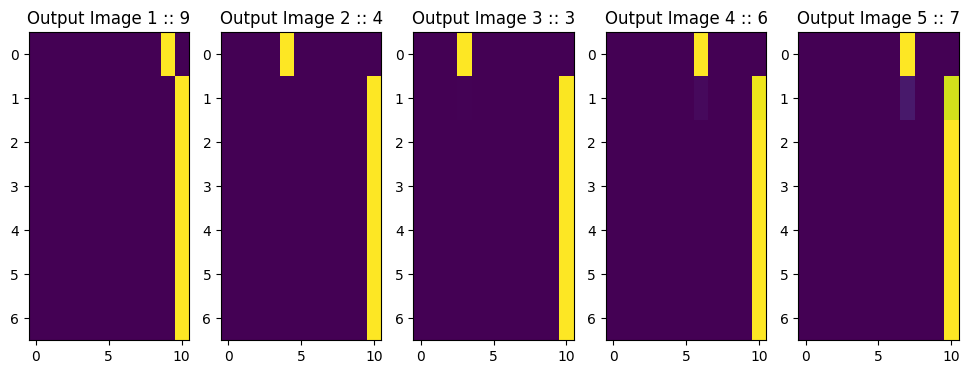

In [14]:
output_model = models.Model(inputs, outputs)
output_features = output_model.predict(dummy_images)

print("Full output shape:", output_features.shape)
fig, axes = plt.subplots(1, output_features.shape[0], figsize=(12, 4))
for i in range(output_features.shape[0]):
    axes[i].imshow(output_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Output Image {i+1} :: {true_labels[i]}")

In [9]:
print(output_features.shape)
output_features

(5, 7, 11)


array([[[3.84740240e-09, 2.41173689e-06, 1.09532506e-04, 2.27748551e-05,
         8.02907834e-06, 9.83973081e-08, 2.79111445e-09, 9.99849498e-01,
         2.85102351e-06, 1.59602928e-06, 3.24810594e-06],
        [4.41084972e-12, 2.18827392e-08, 3.85338666e-07, 6.47612097e-08,
         9.02910580e-10, 3.43022055e-10, 3.55203755e-10, 9.18628939e-06,
         1.10462093e-08, 6.46545151e-10, 9.99990344e-01],
        [3.55364838e-15, 1.31463581e-11, 2.50337268e-11, 1.66263140e-12,
         2.03027916e-12, 3.48132412e-13, 3.57251295e-12, 3.53289481e-11,
         9.61437093e-13, 3.09648208e-14, 1.00000000e+00],
        [5.16693952e-15, 1.67420904e-11, 3.30088773e-14, 1.55914862e-14,
         1.72173758e-13, 2.53730001e-12, 5.12655944e-13, 2.10682708e-13,
         2.87072476e-13, 1.75292113e-14, 1.00000000e+00],
        [1.93760701e-14, 3.92712685e-12, 1.59478686e-14, 1.19161857e-14,
         1.86932951e-15, 1.13712522e-12, 4.34719014e-12, 1.77339121e-14,
         5.60613872e-14, 3.55461103e-1

decoded preds :: log prob
[SparseTensor(indices=tf.Tensor(
[[0 0]
 [1 0]
 [2 0]
 [3 0]
 [4 0]], shape=(5, 2), dtype=int64), values=tf.Tensor([9 4 3 6 7], shape=(5,), dtype=int64), dense_shape=tf.Tensor([5 1], shape=(2,), dtype=int64))] tf.Tensor(
[[0.00070746]
 [0.00069811]
 [0.00550241]
 [0.02669183]
 [0.0702652 ]], shape=(5, 1), dtype=float32)

decoded preds dense
tf.Tensor(
[[9]
 [4]
 [3]
 [6]
 [7]], shape=(5, 1), dtype=int64)

to numpy :: [[9]
 [4]
 [3]
 [6]
 [7]]
to flatten :: [9 4 3 6 7]
predicted digits ::  [9, 4, 3, 6, 7]


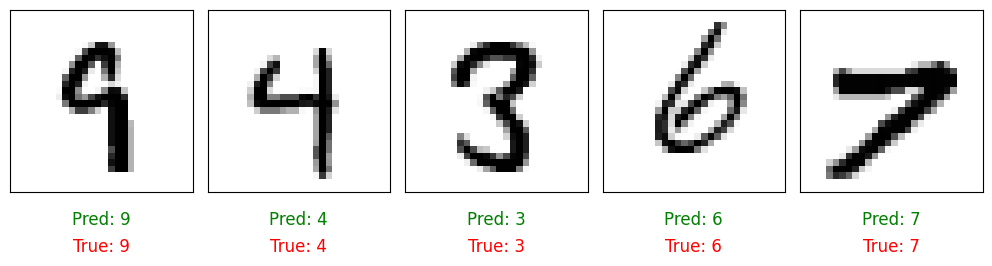

In [15]:
raw_preds = output_features

# Perform CTC decoding using tf.nn.ctc_greedy_decoder
# tf.nn.ctc_greedy_decoder expects inputs with shape [time_steps, batch_size, num_classes]
# Our model output has shape [batch_size, time_steps, num_classes], so we need to transpose it.
transposed_preds = tf.transpose(raw_preds, perm=[1, 0, 2])

# tf.nn.ctc_greedy_decoder also expects log probabilities.
log_probs = tf.math.log(transposed_preds + tf.keras.backend.epsilon())

# The `sequence_length` is the length of the sequence for each example in the batch.
batch_size = tf.shape(raw_preds)[0]
input_length = tf.fill([batch_size], tf.shape(raw_preds)[1]) # all 7

# Perform CTC greedy decoding
decoded_preds, log_prob = tf.nn.ctc_greedy_decoder(log_probs, input_length)
print("decoded preds :: log prob")
print(decoded_preds, log_prob)
print()

# The output of ctc_greedy_decoder is a list of sparse tensors.
# Convert the sparse tensor to a dense tensor for easier handling.
decoded_preds_dense = tf.sparse.to_dense(decoded_preds[0], default_value=-1)
print("decoded preds dense")
print(decoded_preds_dense)
print()

# Turn to actual workable list
print(f"to numpy :: {decoded_preds_dense.numpy()}\nto flatten :: {decoded_preds_dense.numpy().flatten()}" )
predicted_digits = decoded_preds_dense.numpy().flatten().tolist()
print("predicted digits :: ", predicted_digits)

# Display images with decoded predictions
fig = plt.figure(figsize=(12, 8)) # Adjust figure size for better display
for i in range(len(predicted_digits)):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    img = dummy_images[i]
    ax.imshow(img, cmap='gray_r')
    # Display the decoded digit
    ax.text(0.5, -0.15, 'Pred: {}'.format(str(predicted_digits[i])), size=12, color='green',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes)

    # Optionally display the true label for comparison
    ax.text(0.5, -0.3, 'True: {}'.format(true_labels[i]), size=12, color='red',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()
